# Per-Timestep Sensitivity Analysis and Shapley Values

**Textbook Algorithms 11.1 and 11.4** applied to the roundabout policy.

Unlike the scenario-level sweep in `sensitivity_analysis.ipynb`, this notebook
works on a **single failure trajectory** and asks:

- **Sensitivity (Alg 11.1):** At which timestep does perturbing the action
  cause the largest change in robustness?
- **Shapley values (Alg 11.4):** What is the marginal contribution of each
  timestep's action, accounting for interactions between timesteps?

In [1]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import copy
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from stable_baselines3 import DQN

from src import (
    NOMINAL,
    SimulatedEnv,
    ScenarioFuzzer,
    FuzzerConfig,
    weights_from_vector,
)

objc[14716]: Class SDLApplication is implemented in both /opt/miniconda3/envs/highway/lib/python3.10/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x16b104890) and /opt/miniconda3/envs/highway/lib/python3.10/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x17a8752c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[14716]: Class SDLAppDelegate is implemented in both /opt/miniconda3/envs/highway/lib/python3.10/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x16b1048e0) and /opt/miniconda3/envs/highway/lib/python3.10/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x17a875318). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[14716]: Class SDLTranslatorResponder is implemented in both /opt/miniconda3/envs/highway/lib/python3.10/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x16b104958) and /opt/miniconda3/envs/highway/lib/python3.10/site-pa

In [2]:
env = gym.make("SimulatedEnv-v0", render_mode=None, scenario_params=copy.deepcopy(NOMINAL))
obs, info = env.reset()

model = DQN.load("roundabout_dqn/best_model/best_model.zip", env=env, device="cpu")

env.unwrapped.config["simulation_frequency"] = 15
env.unwrapped.config.update({
    "observation": {
        "type": "Kinematics",
        "absolute": True,
        "features_range": {
            "x": [-100, 100],
            "y": [-100, 100],
            "vx": [-15, 15],
            "vy": [-15, 15],
        },
        "vehicles_count": 5,
    },
})

robustness_weights = weights_from_vector([0.2042, 0.1982, 0.4393, 0.0111, 0.1471])

fuzzer = ScenarioFuzzer(
    env, model,
    robustness_weights=robustness_weights,
    config=FuzzerConfig(verbose=False),
    seed=42,
)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
# Find a LONG failure trajectory and record its disturbances.
# Short crashes (< MIN_STEPS) are uninteresting for per-timestep analysis
# because every single action matters roughly equally.
REF_SEED = 42
MAX_ATTEMPTS = 500
MIN_STEPS = 10

ref = None
candidates = []
for attempt in range(MAX_ATTEMPTS):
    np.random.seed(REF_SEED + attempt)
    r = fuzzer.rollout(compute_log_prob=False, return_sensitivity=True)
    rp = r["realized_params"]
    n = len(rp["high_lvl_actions"]["actions"])
    if r["is_failure"]:
        candidates.append((attempt, n, r))
        if n >= MIN_STEPS:
            ref = r
            ref_attempt = attempt
            break

if ref is None and candidates:
    # Fall back to the longest failure we found
    candidates.sort(key=lambda x: x[1], reverse=True)
    ref_attempt, _, ref = candidates[0]
    print(f"No failure with >= {MIN_STEPS} steps found. Using longest available.")

if ref is None:
    print(f"No failure found in {MAX_ATTEMPTS} attempts.")
else:
    rp = ref["realized_params"]
    ref_noise = {
        "position_x": rp["initial_position_x"],
        "position_y": rp["initial_position_y"],
        "velocity_x": rp["velocity_x"],
        "velocity_y": rp["velocity_y"],
    }
    ref_actions = rp["high_lvl_actions"]["actions"]
    ref_available = rp["high_lvl_actions"]["available"]
    n_steps = len(ref_actions)
    ref_robustness = ref["robustness"]

    print(f"Found failure on attempt {ref_attempt}  (seed offset = {REF_SEED + ref_attempt})")
    print(f"  Trajectory length: {n_steps} steps")
    print(f"  Robustness:        {ref_robustness:.4f}")
    print(f"  Action sequence:   {[int(np.asarray(a).flat[0]) for a in ref_actions]}")
    print(f"\nAll failure candidates found: "
          f"{[(a, n) for a, n, _ in candidates[:10]]} ..."
          if len(candidates) > 10 else
          f"\nAll failure candidates: {[(a, n) for a, n, _ in candidates]}")

No failure with >= 15 steps found. Using longest available.
Found failure on attempt 59  (seed offset = 101)
  Trajectory length: 11 steps
  Robustness:        0.0000
  Action sequence:   [3, 3, 1, 3, 1, 1, 3, 3, 3, 3, 3]

All failure candidates found: [(59, 11), (76, 11), (156, 11), (243, 11), (498, 11), (114, 10), (127, 10), (250, 10), (365, 10), (397, 10)] ...


In [4]:
# ── Per-timestep sensitivity analysis (Algorithm 11.1) ──
# For each timestep t, perturb the action at t while keeping everything else
# the same. Sensitivity = std(|robustness_perturbed - robustness_reference|).

M_SAMPLES = 20  # perturbations per timestep

sensitivities = np.zeros(n_steps)
all_perturbed_robs = []

for t in range(n_steps):
    robs_t = []
    for _ in range(M_SAMPLES):
        random_action = int(np.random.choice(ref_available[t]))
        override = {t: random_action}
        r = fuzzer.replay_rollout(
            ref_noise, action_override=override, seed=REF_SEED + ref_attempt,
        )
        robs_t.append(r["robustness"])

    robs_t = np.array(robs_t)
    sensitivities[t] = float(np.std(np.abs(robs_t - ref_robustness)))
    all_perturbed_robs.append(robs_t)

    if (t + 1) % 5 == 0 or t == n_steps - 1:
        print(f"  Timestep {t+1}/{n_steps}  sensitivity={sensitivities[t]:.4f}")

print(f"\nDone. Max sensitivity at timestep {np.argmax(sensitivities)} "
      f"(score={np.max(sensitivities):.4f})")

  Timestep 5/11  sensitivity=0.1045
  Timestep 10/11  sensitivity=0.0828
  Timestep 11/11  sensitivity=0.0802

Done. Max sensitivity at timestep 0 (score=0.1956)


/var/folders/33/0zr03g3d515_77qtwgqdv7n40000gn/T/ipykernel_14716/2203758567.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


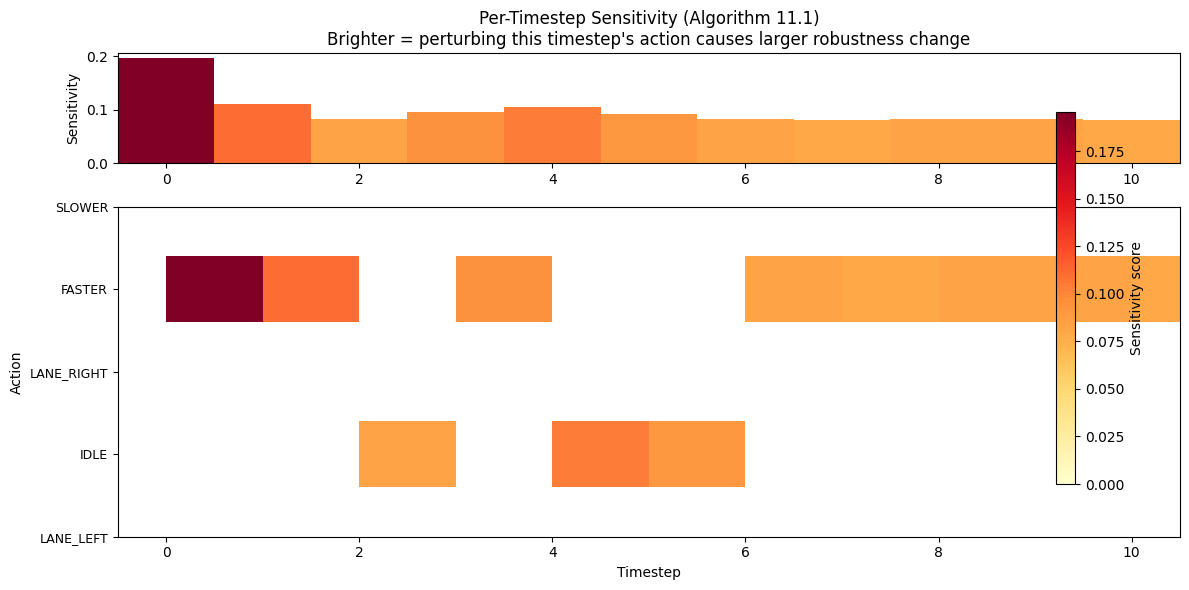

In [5]:
# ── Sensitivity heatmap (textbook Figure 11.5 style) ──
fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={"height_ratios": [1, 3]})

# Top: bar chart of sensitivity per timestep
ax_bar = axes[0]
norm = mcolors.Normalize(vmin=0, vmax=max(sensitivities.max(), 1e-8))
cmap = plt.cm.YlOrRd
colors = cmap(norm(sensitivities))
ax_bar.bar(range(n_steps), sensitivities, color=colors, edgecolor="none", width=1.0)
ax_bar.set_ylabel("Sensitivity")
ax_bar.set_xlim(-0.5, n_steps - 0.5)
ax_bar.set_title("Per-Timestep Sensitivity (Algorithm 11.1)\n"
                  "Brighter = perturbing this timestep's action causes larger robustness change")

# Bottom: action sequence with color-coded sensitivity
ax_act = axes[1]
action_labels = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}
action_ints = [int(np.asarray(a).flat[0]) for a in ref_actions]

for t, a in enumerate(action_ints):
    ax_act.barh(a, 1, left=t, color=cmap(norm(sensitivities[t])),
                edgecolor="none", height=0.8)

ax_act.set_xlabel("Timestep")
ax_act.set_ylabel("Action")
ax_act.set_yticks(list(action_labels.keys()))
ax_act.set_yticklabels(list(action_labels.values()), fontsize=9)
ax_act.set_xlim(-0.5, n_steps - 0.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Sensitivity score")

plt.tight_layout()
plt.show()

In [6]:
# ── Shapley values (Algorithm 11.4) ──
# For each timestep t, estimate its marginal contribution to robustness
# by averaging over random permutations of timesteps.
#
# For each permutation P, let j = index of t in P.
#   tau_plus  = replay with reference actions at P[0:j]   (including t)
#               and random actions at all other timesteps
#   tau_minus = replay with reference actions at P[0:j-1]  (excluding t)
#               and random actions at all other timesteps
#   contribution = robustness(tau_plus) - robustness(tau_minus)

M_SHAPLEY = 20  # permutations per timestep

shapley_values = np.zeros(n_steps)
timesteps = list(range(n_steps))

for t in range(n_steps):
    contributions = []
    for _ in range(M_SHAPLEY):
        perm = np.random.permutation(n_steps)
        j = int(np.where(perm == t)[0][0])

        # Indices with reference actions (from the permutation up to and including j)
        ref_set_plus = set(perm[:j + 1])
        ref_set_minus = set(perm[:j])

        # Build action overrides: random actions for timesteps NOT in the ref set
        override_plus = {}
        override_minus = {}
        for s in range(n_steps):
            rand_a = int(np.random.choice(ref_available[s]))
            if s not in ref_set_plus:
                override_plus[s] = rand_a
            if s not in ref_set_minus:
                override_minus[s] = rand_a

        r_plus = fuzzer.replay_rollout(
            ref_noise, action_override=override_plus, seed=REF_SEED + ref_attempt,
        )
        r_minus = fuzzer.replay_rollout(
            ref_noise, action_override=override_minus, seed=REF_SEED + ref_attempt,
        )

        contributions.append(r_plus["robustness"] - r_minus["robustness"])

    shapley_values[t] = float(np.mean(contributions))

    if (t + 1) % 5 == 0 or t == n_steps - 1:
        print(f"  Timestep {t+1}/{n_steps}  Shapley={shapley_values[t]:.4f}")

print(f"\nDone. Largest |Shapley| at timestep {np.argmax(np.abs(shapley_values))} "
      f"(value={shapley_values[np.argmax(np.abs(shapley_values))]:.4f})")

  Timestep 5/11  Shapley=0.0186
  Timestep 10/11  Shapley=0.0298
  Timestep 11/11  Shapley=0.0212

Done. Largest |Shapley| at timestep 0 (value=0.1619)


/var/folders/33/0zr03g3d515_77qtwgqdv7n40000gn/T/ipykernel_14716/3613910909.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


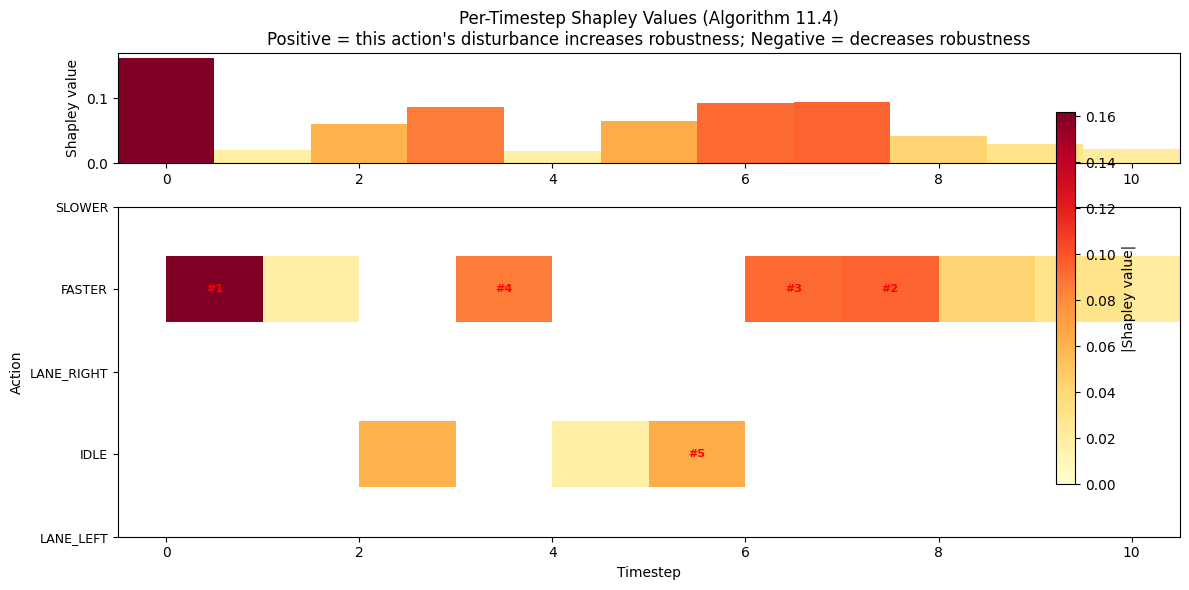

In [7]:
# ── Shapley value visualization (textbook Figure 11.9 style) ──
fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={"height_ratios": [1, 3]})

abs_shap = np.abs(shapley_values)
norm_shap = mcolors.Normalize(vmin=0, vmax=max(abs_shap.max(), 1e-8))

ax_bar = axes[0]
bar_colors = cmap(norm_shap(abs_shap))
ax_bar.bar(range(n_steps), shapley_values, color=bar_colors, edgecolor="none", width=1.0)
ax_bar.axhline(0, color="black", linewidth=0.5)
ax_bar.set_ylabel("Shapley value")
ax_bar.set_xlim(-0.5, n_steps - 0.5)
ax_bar.set_title("Per-Timestep Shapley Values (Algorithm 11.4)\n"
                  "Positive = this action's disturbance increases robustness; "
                  "Negative = decreases robustness")

ax_act = axes[1]
for t_idx, a in enumerate(action_ints):
    ax_act.barh(a, 1, left=t_idx, color=cmap(norm_shap(abs_shap[t_idx])),
                edgecolor="none", height=0.8)

# Mark top-5 most important timesteps
top_k = 5
top_indices = np.argsort(abs_shap)[-top_k:][::-1]
for rank, ti in enumerate(top_indices):
    ax_act.annotate(f"#{rank+1}", (ti + 0.5, action_ints[ti]),
                    fontsize=8, fontweight="bold", color="red",
                    ha="center", va="center")

ax_act.set_xlabel("Timestep")
ax_act.set_ylabel("Action")
ax_act.set_yticks(list(action_labels.keys()))
ax_act.set_yticklabels(list(action_labels.values()), fontsize=9)
ax_act.set_xlim(-0.5, n_steps - 0.5)

sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=norm_shap)
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar2.set_label("|Shapley value|")

plt.tight_layout()
plt.show()

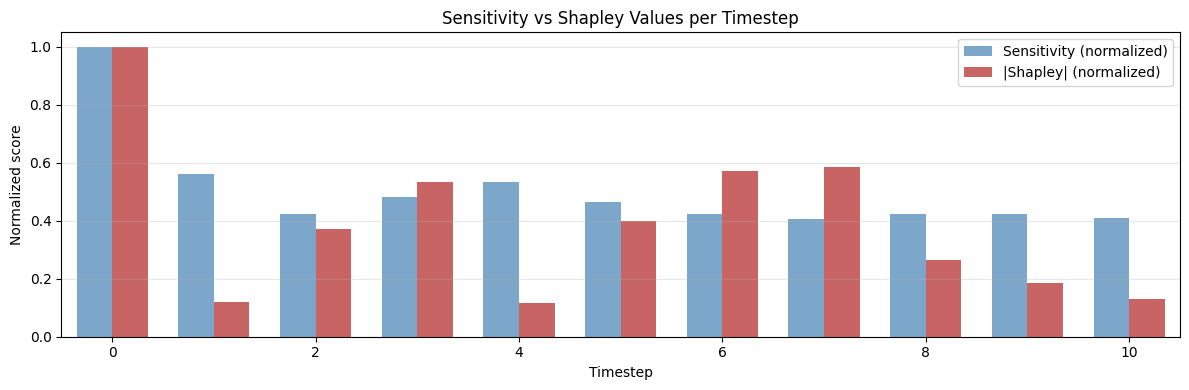


   t        Action   Sensitivity     Shapley   |Shapley|
───────────────────────────────────────────────────────
   0        FASTER        0.1956      0.1619      0.1619
   1        FASTER        0.1100      0.0196      0.0196
   2          IDLE        0.0825      0.0602      0.0602
   3        FASTER        0.0945      0.0866      0.0866
   4          IDLE        0.1045      0.0186      0.0186
   5          IDLE        0.0911      0.0647      0.0647
   6        FASTER        0.0831      0.0923      0.0923
   7        FASTER        0.0797      0.0948      0.0948
   8        FASTER        0.0831      0.0426      0.0426
   9        FASTER        0.0828      0.0298      0.0298
  10        FASTER        0.0802      0.0212      0.0212

Top-5 most important timesteps by |Shapley|:
  #1: t=0 (FASTER), Shapley=0.1619, Sensitivity=0.1956
  #2: t=7 (FASTER), Shapley=0.0948, Sensitivity=0.0797
  #3: t=6 (FASTER), Shapley=0.0923, Sensitivity=0.0831
  #4: t=3 (FASTER), Shapley=0.0866, Sensitivity=

In [8]:
# ── Comparison: Sensitivity vs Shapley ──
fig, ax = plt.subplots(figsize=(12, 4))

x = np.arange(n_steps)
width = 0.35
ax.bar(x - width / 2, sensitivities / max(sensitivities.max(), 1e-8),
       width, label="Sensitivity (normalized)", color="steelblue", alpha=0.7)
ax.bar(x + width / 2, abs_shap / max(abs_shap.max(), 1e-8),
       width, label="|Shapley| (normalized)", color="firebrick", alpha=0.7)

ax.set_xlabel("Timestep")
ax.set_ylabel("Normalized score")
ax.set_title("Sensitivity vs Shapley Values per Timestep")
ax.legend()
ax.set_xlim(-0.5, n_steps - 0.5)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Ranked comparison table
print(f"\n{'t':>4}  {'Action':>12}  {'Sensitivity':>12}  {'Shapley':>10}  {'|Shapley|':>10}")
print("─" * 55)
for t_idx in range(n_steps):
    a_name = action_labels.get(action_ints[t_idx], str(action_ints[t_idx]))
    print(f"{t_idx:>4}  {a_name:>12}  {sensitivities[t_idx]:>12.4f}  "
          f"{shapley_values[t_idx]:>10.4f}  {abs_shap[t_idx]:>10.4f}")

print(f"\nTop-{top_k} most important timesteps by |Shapley|:")
for rank, ti in enumerate(top_indices):
    a_name = action_labels.get(action_ints[ti], str(action_ints[ti]))
    print(f"  #{rank+1}: t={ti} ({a_name}), Shapley={shapley_values[ti]:.4f}, "
          f"Sensitivity={sensitivities[ti]:.4f}")